In [43]:
import pandas as pd

df = pd.read_csv("../data/softball_data.csv")
teams = pd.read_csv("../data/team_summary.csv"

In [44]:
import pandas as pd

df_final = pd.read_csv("../data/softball_data.csv")
df_final.head()

,team,year,opponent,date,outcome,score,score_for,score_against,score_diff,total_points,win,margin_type,win_flag
0,california-lutheran,2019,la-verne,2019-02-16 12:00:00,L,4-11,4.0,11.0,-7.0,15.0,False,blowout,0
1,california-lutheran,2019,la-verne,2019-02-16 14:00:00,L,4-6,4.0,6.0,-2.0,10.0,False,close,0
2,california-lutheran,2019,claremont-mudd-scripps,2019-02-23 12:00:00,L,6-9,6.0,9.0,-3.0,15.0,False,moderate,0
3,california-lutheran,2019,claremont-mudd-scripps,2019-02-23 14:00:00,L,0-10,0.0,10.0,-10.0,10.0,False,blowout,0
4,california-lutheran,2019,hiram,2019-03-04 12:00:00,W,5-1,5.0,1.0,4.0,6.0,True,moderate,1


### New Dataset

In [45]:
import pandas as pd

schools = [
    {"school": "california-lutheran", "enrollment": 2297, "city": "Thousand Oaks", "state": "CA", "lat": 34.226, "lon": -118.879},
    {"school": "redlands", "enrollment": 2045, "city": "Redlands", "state": "CA", "lat": 34.063, "lon": -117.164},
    {"school": "chapman", "enrollment": 7713, "city": "Orange", "state": "CA", "lat": 33.793, "lon": -117.851},
    {"school": "pomona-pitzer", "enrollment": 3008, "city": "Claremont", "state": "CA", "lat": 34.097, "lon": -117.711}, # total pomona and pitzer college
    {"school": "whittier", "enrollment": 767, "city": "Whittier", "state": "CA", "lat": 33.977, "lon": -118.032},
    {"school": "occidental", "enrollment": 1881, "city": "Los Angeles", "state": "CA", "lat": 34.126, "lon": -118.213},
    {"school": "la-verne", "enrollment": 3050, "city": "La Verne", "state": "CA", "lat": 34.100, "lon": -117.771}
]

df_schools = pd.DataFrame(schools)

df_schools

,school,enrollment,city,state,lat,lon
0,california-lutheran,2297,Thousand Oaks,CA,34.226,-118.879
1,redlands,2045,Redlands,CA,34.063,-117.164
2,chapman,7713,Orange,CA,33.793,-117.851
3,pomona-pitzer,3008,Claremont,CA,34.097,-117.711
4,whittier,767,Whittier,CA,33.977,-118.032
5,occidental,1881,Los Angeles,CA,34.126,-118.213
6,la-verne,3050,La Verne,CA,34.100,-117.771


### Merge Datasets

In [46]:
df_merged = df_final.merge(
    df_schools,
    how="left",
    left_on="team",
    right_on="school"
)

df_merged.head()

,team,year,opponent,date,outcome,score,score_for,score_against,score_diff,total_points,win,margin_type,win_flag,school,enrollment,city,state,lat,lon
0,california-lutheran,2019,la-verne,2019-02-16 12:00:00,L,4-11,4.0,11.0,-7.0,15.0,False,blowout,0,california-lutheran,2297,Thousand Oaks,CA,34.226,-118.879
1,california-lutheran,2019,la-verne,2019-02-16 14:00:00,L,4-6,4.0,6.0,-2.0,10.0,False,close,0,california-lutheran,2297,Thousand Oaks,CA,34.226,-118.879
2,california-lutheran,2019,claremont-mudd-scripps,2019-02-23 12:00:00,L,6-9,6.0,9.0,-3.0,15.0,False,moderate,0,california-lutheran,2297,Thousand Oaks,CA,34.226,-118.879
3,california-lutheran,2019,claremont-mudd-scripps,2019-02-23 14:00:00,L,0-10,0.0,10.0,-10.0,10.0,False,blowout,0,california-lutheran,2297,Thousand Oaks,CA,34.226,-118.879
4,california-lutheran,2019,hiram,2019-03-04 12:00:00,W,5-1,5.0,1.0,4.0,6.0,True,moderate,1,california-lutheran,2297,Thousand Oaks,CA,34.226,-118.879


In [47]:
df_merged.isna().sum()

team                0
year                0
opponent          548
date             1125
outcome           326
score             326
score_for         326
score_against     326
score_diff        326
total_points      326
win                 0
margin_type       326
win_flag            0
school              0
enrollment          0
city                0
state               0
lat                 0
lon                 0
dtype: int64

### Cleaning

In [48]:
df_clean = df_merged.dropna(subset=["outcome"])

In [49]:
df_clean.shape

(1899, 19)

In [50]:
df_clean.isna().sum()

team               0
year               0
opponent         464
date             971
outcome            0
score              0
score_for          0
score_against      0
score_diff         0
total_points       0
win                0
margin_type        0
win_flag           0
school             0
enrollment         0
city               0
state              0
lat                0
lon                0
dtype: int64

In [51]:
# Define SCIAC Teams
sciac_teams = [
    "california-lutheran",
    "redlands",
    "chapman",
    "pomona-pitzer",
    "whittier",
    "occidental",
    "la-verne",
    "claremont-mudd-scripps"
]

In [52]:
df_clean["is_sciac_game"] = df_clean["opponent"].isin(sciac_teams)

In [53]:
df_clean["is_sciac_game"].value_counts()

is_sciac_game
False    1027
True      872
Name: count, dtype: int64

In [54]:
df_clean[df_clean["is_sciac_game"] == True]["opponent"].value_counts()

opponent
chapman                   124
claremont-mudd-scripps    122
redlands                  122
california-lutheran       109
occidental                105
pomona-pitzer             101
la-verne                  100
whittier                   89
Name: count, dtype: int64

In [55]:
df_clean = df_clean.copy()

In [56]:
df_clean["date"] = pd.to_datetime(df_clean["date"], errors="coerce")

In [57]:
df_clean["year"] = df_clean["date"].dt.year

In [58]:
df_clean.to_csv("clean_softball_data.csv", index=False)

### Team Stats

In [59]:
team_stats = df_clean.groupby("team").agg(
    total_games=("win_flag", "count"),
    wins=("win_flag", "sum"),
    win_pct=("win_flag", "mean"),
    avg_runs_scored=("score_for", "mean"),
    avg_runs_allowed=("score_against", "mean")
).reset_index()

team_stats

,team,total_games,wins,win_pct,avg_runs_scored,avg_runs_allowed
0,california-lutheran,208,78,0.375000,4.350962,6.052885
1,chapman,254,150,0.590551,4.598425,3.893701
2,la-verne,220,107,0.486364,4.545455,4.522727
3,occidental,464,96,0.206897,3.219828,6.590517
4,pomona-pitzer,250,137,0.548000,5.032000,4.088000
5,redlands,258,167,0.647287,5.864341,4.189922
6,whittier,245,128,0.522449,5.220408,4.861224


### Final Merge

In [60]:
team_analysis = team_stats.merge(
    df_schools,
    how="left",
    left_on="team",
    right_on="school"
)

team_analysis

,team,total_games,wins,win_pct,avg_runs_scored,avg_runs_allowed,school,enrollment,city,state,lat,lon
0,california-lutheran,208,78,0.375000,4.350962,6.052885,california-lutheran,2297,Thousand Oaks,CA,34.226,-118.879
1,chapman,254,150,0.590551,4.598425,3.893701,chapman,7713,Orange,CA,33.793,-117.851
2,la-verne,220,107,0.486364,4.545455,4.522727,la-verne,3050,La Verne,CA,34.100,-117.771
3,occidental,464,96,0.206897,3.219828,6.590517,occidental,1881,Los Angeles,CA,34.126,-118.213
4,pomona-pitzer,250,137,0.548000,5.032000,4.088000,pomona-pitzer,3008,Claremont,CA,34.097,-117.711
5,redlands,258,167,0.647287,5.864341,4.189922,redlands,2045,Redlands,CA,34.063,-117.164
6,whittier,245,128,0.522449,5.220408,4.861224,whittier,767,Whittier,CA,33.977,-118.032


In [61]:
team_analysis.to_csv("team_summary.csv", index=False)

## Visualizations

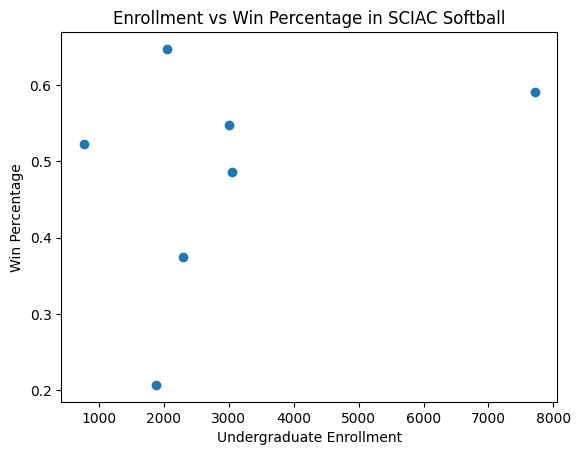

In [62]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(team_analysis["enrollment"], team_analysis["win_pct"])

plt.xlabel("Undergraduate Enrollment")
plt.ylabel("Win Percentage")
plt.title("Enrollment vs Win Percentage in SCIAC Softball")
plt.show()

In [63]:
import nbformat
print(nbformat.__version__)

5.10.4


In [64]:
import plotly.express as px
import numpy as np

# -----------------------------
# Copy data
# -----------------------------
map_df = team_analysis.copy()

# -----------------------------
# Run differential
# -----------------------------
map_df["run_diff"] = (
    map_df["avg_runs_scored"] -
    map_df["avg_runs_allowed"]
)

# -----------------------------
# Strength index
# -----------------------------
map_df["strength_index"] = (
    map_df["win_pct"] * 0.6 +
    (map_df["run_diff"] / map_df["run_diff"].max()) * 0.4
)

# -----------------------------
# Scale enrollment sizes
# -----------------------------
map_df["enrollment_scaled"] = np.sqrt(map_df["enrollment"])

map_df["enrollment_scaled"] = (
    map_df["enrollment_scaled"] /
    map_df["enrollment_scaled"].max()
) * 30

# -----------------------------
# NEW MAP FUNCTION
# -----------------------------
fig = px.scatter_map(
    map_df,
    lat="lat",
    lon="lon",
    color="strength_index",
    size="enrollment_scaled",
    hover_name="school",
    hover_data={
        "enrollment": True,
        "win_pct": ':.3f',
        "run_diff": ':.2f',
        "strength_index": ':.3f',
        "lat": False,
        "lon": False,
        "enrollment_scaled": False
    },
    zoom=5.5,
    title="SCIAC Softball Program Strength (2019–2025)"
)

fig.show()

### Win Percentage by Year Visualizations

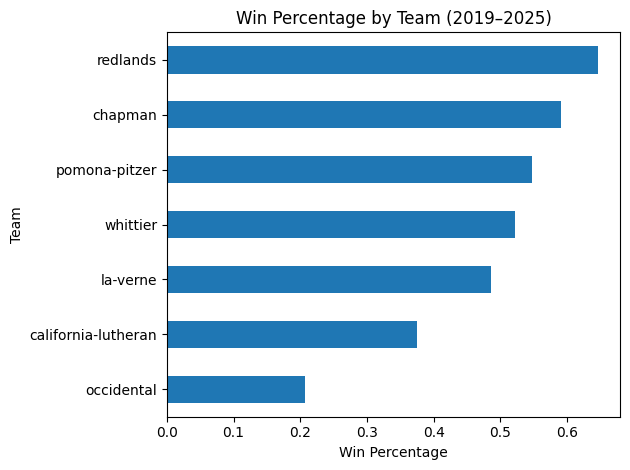

In [65]:
import matplotlib.pyplot as plt

team_win = df_clean.groupby("team")["win_flag"].mean().sort_values()

plt.figure()
team_win.plot(kind="barh")

plt.title("Win Percentage by Team (2019–2025)")
plt.xlabel("Win Percentage")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

In [66]:
df_clean.groupby(["team", "year"]).size().unstack(fill_value=0)

year,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0
team,,,,,,,
california-lutheran,40,12,14,34,34,28,32
chapman,41,15,19,40,40,0,0
la-verne,40,15,8,37,36,37,35
pomona-pitzer,34,9,0,37,40,0,0
redlands,37,9,16,38,35,0,0
whittier,39,8,0,34,35,0,0


In [67]:
df_merged["outcome"].isna().sum()

np.int64(326)

In [68]:
df_merged[
    (df_merged["team"] == "chapman") & (df_merged["year"] >= 2024)
][["year", "outcome", "score"]]

,year,outcome,score
741,2024,L,2-5
742,2024,L,0-8
743,2024,W,4-3
744,2024,L,2-5
745,2024,L,0-3
...,...,...,...
830,2025,W,4-0
831,2025,L,4-7
832,2025,W,5-0
833,2025,W,10-1


In [69]:
df_merged[df_merged["year"].isin([2024, 2025])]["outcome"].isna().sum()

np.int64(38)

In [70]:
df_merged[df_merged["year"].isin([2024, 2025])].groupby("team")["outcome"].apply(lambda x: x.isna().sum())

team
california-lutheran     3
chapman                 6
la-verne                4
occidental              6
pomona-pitzer           2
redlands               13
whittier                4
Name: outcome, dtype: int64

In [71]:
df_clean = df_merged[df_merged["outcome"].notna()].copy()

In [72]:
df_clean.groupby(["team", "year"]).size().unstack(fill_value=0)

year,2019,2020,2021,2022,2023,2024,2025
team,,,,,,,
california-lutheran,40,12,18,37,34,34,33
chapman,42,16,23,42,43,44,44
la-verne,40,16,8,42,38,37,39
occidental,78,26,60,80,72,72,76
pomona-pitzer,44,11,34,43,41,38,39
redlands,40,15,21,40,44,47,51
whittier,45,14,34,39,37,36,40


In [73]:
df_clean.groupby(["team", "year"]).size().unstack(fill_value=0)

year,2019,2020,2021,2022,2023,2024,2025
team,,,,,,,
california-lutheran,40,12,18,37,34,34,33
chapman,42,16,23,42,43,44,44
la-verne,40,16,8,42,38,37,39
occidental,78,26,60,80,72,72,76
pomona-pitzer,44,11,34,43,41,38,39
redlands,40,15,21,40,44,47,51
whittier,45,14,34,39,37,36,40


In [74]:
win_time = df_clean.groupby(["team", "year"]).size().unstack(fill_value=0)

In [75]:
df_clean["outcome"] = df_clean["outcome"].str.strip()

In [76]:
df_clean["win_flag"] = (df_clean["outcome"] == "W").astype(int)

In [77]:
win_time = df_clean.groupby(["year", "team"])["win_flag"].mean().reset_index()

In [78]:
win_time.groupby("year")["team"].nunique()

year
2019    7
2020    7
2021    7
2022    7
2023    7
2024    7
2025    7
Name: team, dtype: int64

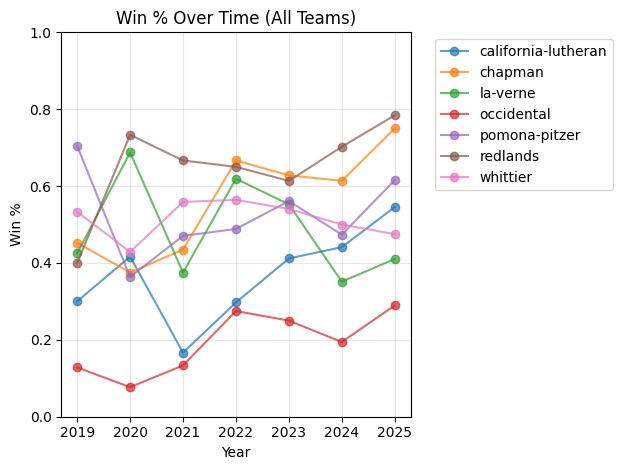

In [79]:
plt.figure()

for team in win_time["team"].unique():
    subset = win_time[win_time["team"] == team].sort_values("year")

    plt.plot(
        subset["year"],
        subset["win_flag"],
        marker='o',
        alpha=0.7,
        label=team
    )

plt.title("Win % Over Time (All Teams)")
plt.xlabel("Year")
plt.ylabel("Win %")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# 👇 move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # prevents cutoff

plt.show()

### Distribution of Scores

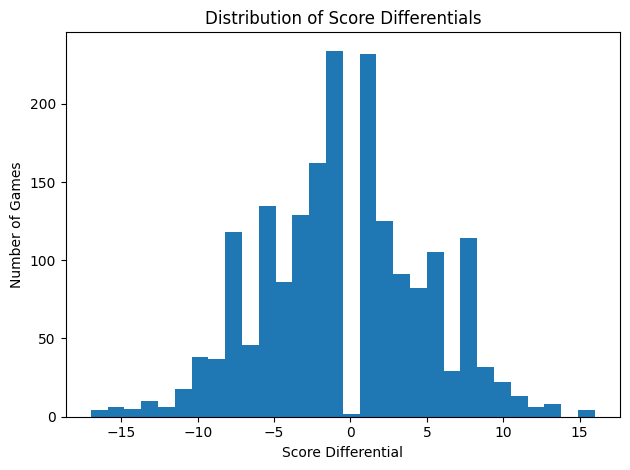

In [80]:
plt.figure()

plt.hist(df_clean["score_diff"], bins=30)

plt.title("Distribution of Score Differentials")
plt.xlabel("Score Differential")
plt.ylabel("Number of Games")

plt.tight_layout()
plt.show()

### Offense vs Defense

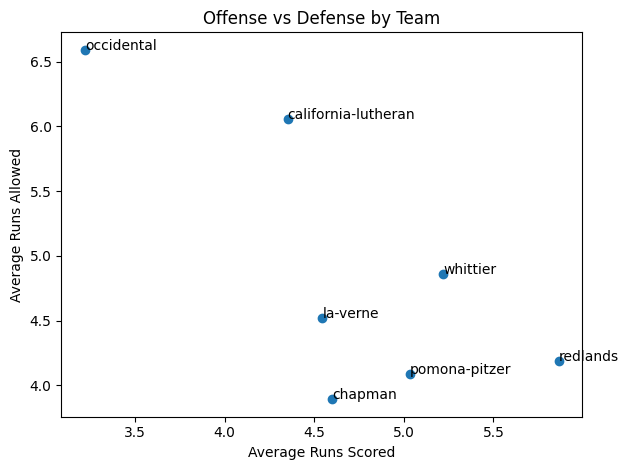

In [81]:
plt.figure()

plt.scatter(
    team_analysis["avg_runs_scored"],
    team_analysis["avg_runs_allowed"]
)

for i, team in enumerate(team_analysis["team"]):
    plt.text(
        team_analysis["avg_runs_scored"][i],
        team_analysis["avg_runs_allowed"][i],
        team
    )

plt.title("Offense vs Defense by Team")
plt.xlabel("Average Runs Scored")
plt.ylabel("Average Runs Allowed")

plt.tight_layout()
plt.show()

### Enrollment vs Win Percentage

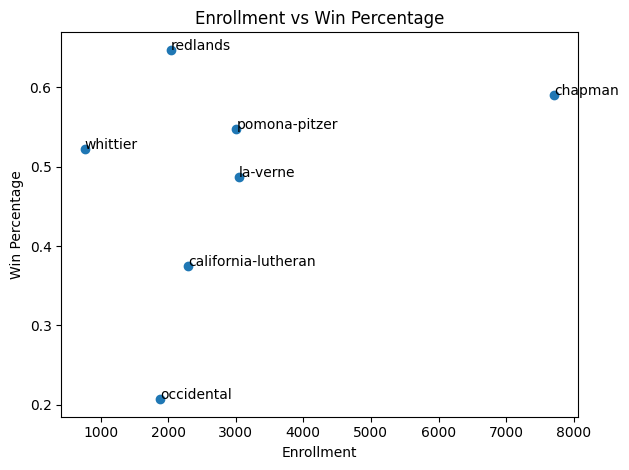

In [82]:
plt.figure()

plt.scatter(
    team_analysis["enrollment"],
    team_analysis["win_pct"]
)

for i, team in enumerate(team_analysis["team"]):
    plt.text(
        team_analysis["enrollment"][i],
        team_analysis["win_pct"][i],
        team
    )

plt.title("Enrollment vs Win Percentage")
plt.xlabel("Enrollment")
plt.ylabel("Win Percentage")

plt.tight_layout()
plt.show()

In [83]:
df_clean["year"].value_counts().sort_index()
df_clean["team"].nunique()
df_clean.isna().sum()

team               0
year               0
opponent         464
date             971
outcome            0
score              0
score_for          0
score_against      0
score_diff         0
total_points       0
win                0
margin_type        0
win_flag           0
school             0
enrollment         0
city               0
state              0
lat                0
lon                0
dtype: int64

In [84]:
df_clean["year"].value_counts().sort_index()
df_clean["team"].nunique()
df_clean.isna().sum()

team               0
year               0
opponent         464
date             971
outcome            0
score              0
score_for          0
score_against      0
score_diff         0
total_points       0
win                0
margin_type        0
win_flag           0
school             0
enrollment         0
city               0
state              0
lat                0
lon                0
dtype: int64

In [107]:
extra_data = [
    {
        "team": "california-lutheran",
        "acceptance_rate": 76,
        "tuition": 53650,
        "coach_changes": 2
    },
    {
        "team": "occidental",
        "acceptance_rate": 44,
        "tuition": 70492,
        "coach_changes": 3
    },
    {
        "team": "whittier",
        "acceptance_rate": 83,
        "tuition": 51917,
        "coach_changes": 2
    },
    {
        "team": "pomona-pitzer",
        "acceptance_rate": 14.5,
        "tuition": 81577,
        "coach_changes": 1
    },
    {
        "team": "la-verne",
        "acceptance_rate": 48.5,
        "tuition": 49550,
        "coach_changes": 3
    },
    {
        "team": "chapman",
        "acceptance_rate": 65,
        "tuition": 69990,
        "coach_changes": 1
    },
    {
        "team": "redlands",
        "acceptance_rate": 83,
        "tuition": 61932,
        "coach_changes": 1
    }
]

In [108]:
extra_df = pd.DataFrame(extra_data)

extra_df

,team,acceptance_rate,tuition,coach_changes
0,california-lutheran,76.0,53650,2
1,occidental,44.0,70492,3
2,whittier,83.0,51917,2
3,pomona-pitzer,14.5,81577,1
4,la-verne,48.5,49550,3
5,chapman,65.0,69990,1
6,redlands,83.0,61932,1


In [109]:
extra_df = pd.DataFrame(extra_data)

final_analysis_df = team_analysis.merge(
    extra_df,
    how="left",
    on="team"
)

final_analysis_df.head(7)

,team,total_games,wins,win_pct,avg_runs_scored,avg_runs_allowed,enrollment,city,state,lat,lon,acceptance_rate,tuition,coach_changes
0,california-lutheran,208,78,0.375000,4.350962,6.052885,2297,Thousand Oaks,CA,34.226,-118.879,76.0,53650,2
1,chapman,254,150,0.590551,4.598425,3.893701,7713,Orange,CA,33.793,-117.851,65.0,69990,1
2,la-verne,220,107,0.486364,4.545455,4.522727,3050,La Verne,CA,34.100,-117.771,48.5,49550,3
3,occidental,464,96,0.206897,3.219828,6.590517,1881,Los Angeles,CA,34.126,-118.213,44.0,70492,3
4,pomona-pitzer,250,137,0.548000,5.032000,4.088000,3008,Claremont,CA,34.097,-117.711,14.5,81577,1
5,redlands,258,167,0.647287,5.864341,4.189922,2045,Redlands,CA,34.063,-117.164,83.0,61932,1
6,whittier,245,128,0.522449,5.220408,4.861224,767,Whittier,CA,33.977,-118.032,83.0,51917,2


In [110]:
# Clean team_analysis back to original columns
team_analysis = team_analysis[[
    "team",
    "total_games",
    "wins",
    "win_pct",
    "avg_runs_scored",
    "avg_runs_allowed",
    "enrollment",
    "city",
    "state",
    "lat",
    "lon"
]]

# Check columns
team_analysis.columns

Index(['team', 'total_games', 'wins', 'win_pct', 'avg_runs_scored',
       'avg_runs_allowed', 'enrollment', 'city', 'state', 'lat', 'lon'],
      dtype='str')

In [111]:
def stability_label(changes):
    if changes == 1:
        return "high"
    elif changes == 2:
        return "medium"
    else:
        return "low"

final_analysis_df["coach_stability"] = (
    final_analysis_df["coach_changes"]
    .apply(stability_label)
)

In [112]:
final_analysis_df["run_diff"] = (
    final_analysis_df["avg_runs_scored"]
    - final_analysis_df["avg_runs_allowed"]
)

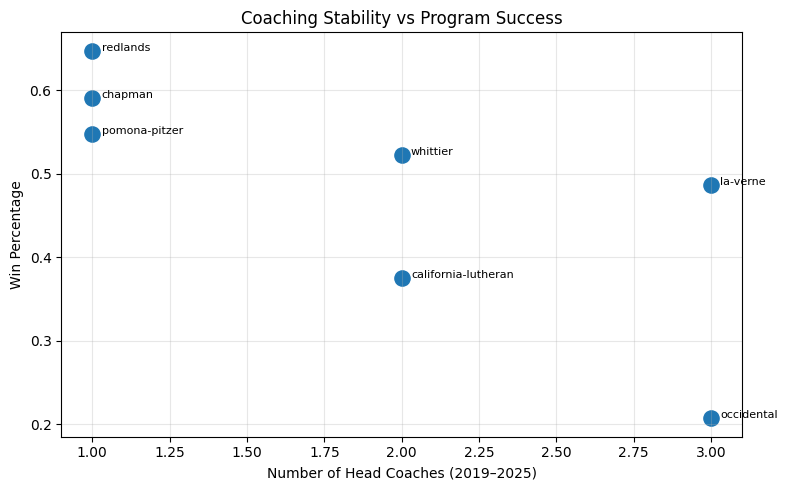

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    final_analysis_df["coach_changes"],
    final_analysis_df["win_pct"],
    s=120
)

for i, team in enumerate(final_analysis_df["team"]):
    plt.text(
        final_analysis_df["coach_changes"][i] + 0.03,
        final_analysis_df["win_pct"][i],
        team,
        fontsize=8
    )

plt.xlabel("Number of Head Coaches (2019–2025)")
plt.ylabel("Win Percentage")
plt.title("Coaching Stability vs Program Success")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

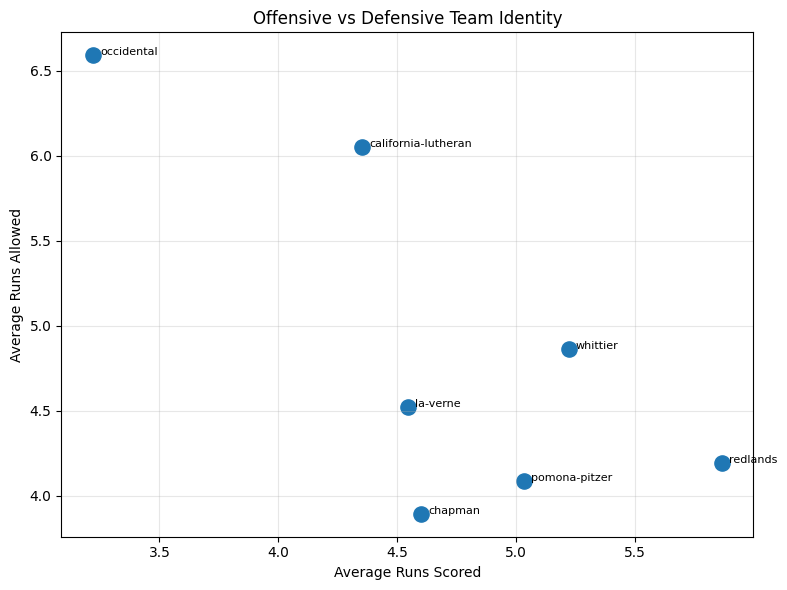

In [114]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_analysis_df["avg_runs_scored"],
    final_analysis_df["avg_runs_allowed"],
    s=120
)

for i, team in enumerate(final_analysis_df["team"]):
    plt.text(
        final_analysis_df["avg_runs_scored"][i] + 0.03,
        final_analysis_df["avg_runs_allowed"][i],
        team,
        fontsize=8
    )

plt.xlabel("Average Runs Scored")
plt.ylabel("Average Runs Allowed")
plt.title("Offensive vs Defensive Team Identity")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

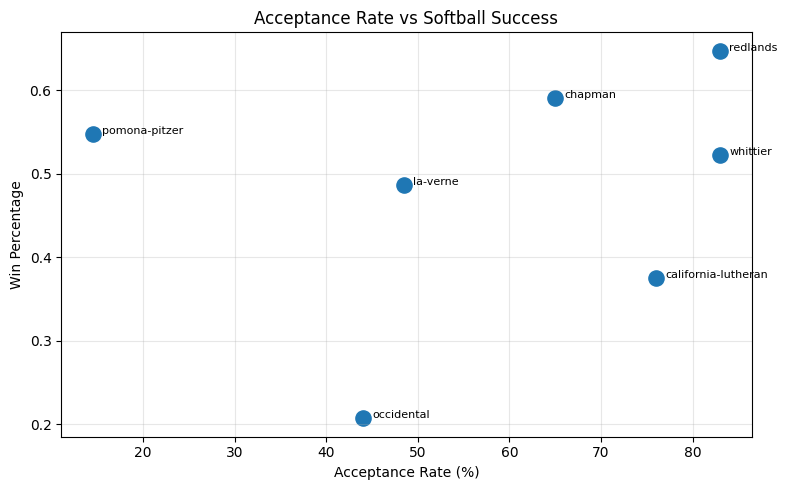

In [115]:
plt.figure(figsize=(8,5))

plt.scatter(
    final_analysis_df["acceptance_rate"],
    final_analysis_df["win_pct"],
    s=120
)

for i, team in enumerate(final_analysis_df["team"]):
    plt.text(
        final_analysis_df["acceptance_rate"][i] + 1,
        final_analysis_df["win_pct"][i],
        team,
        fontsize=8
    )

plt.xlabel("Acceptance Rate (%)")
plt.ylabel("Win Percentage")
plt.title("Acceptance Rate vs Softball Success")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [116]:
final_analysis_df["run_diff"] = (
    final_analysis_df["avg_runs_scored"]
    - final_analysis_df["avg_runs_allowed"]
)

run_diff_rank = final_analysis_df.sort_values(
    by="run_diff",
    ascending=False
)

run_diff_rank[[
    "team",
    "win_pct",
    "run_diff",
    "coach_stability"
]]

,team,win_pct,run_diff,coach_stability
5,redlands,0.647287,1.674419,high
4,pomona-pitzer,0.548000,0.944000,high
1,chapman,0.590551,0.704724,high
6,whittier,0.522449,0.359184,medium
2,la-verne,0.486364,0.022727,low
0,california-lutheran,0.375000,-1.701923,medium
3,occidental,0.206897,-3.370690,low


In [117]:
def program_tier(win_pct):
    if win_pct >= 0.60:
        return "Elite"
    elif win_pct >= 0.45:
        return "Competitive"
    else:
        return "Rebuilding"

final_analysis_df["program_tier"] = (
    final_analysis_df["win_pct"]
    .apply(program_tier)
)

final_analysis_df[[
    "team",
    "win_pct",
    "run_diff",
    "coach_stability",
    "program_tier"
]]

,team,win_pct,run_diff,coach_stability,program_tier
0,california-lutheran,0.375000,-1.701923,medium,Rebuilding
1,chapman,0.590551,0.704724,high,Competitive
2,la-verne,0.486364,0.022727,low,Competitive
3,occidental,0.206897,-3.370690,low,Rebuilding
4,pomona-pitzer,0.548000,0.944000,high,Competitive
5,redlands,0.647287,1.674419,high,Elite
6,whittier,0.522449,0.359184,medium,Competitive


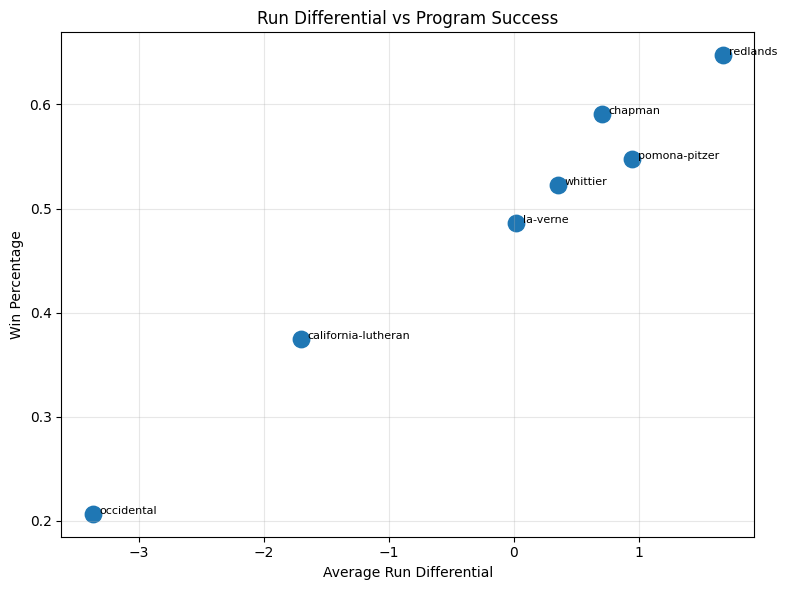

In [118]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_analysis_df["run_diff"],
    final_analysis_df["win_pct"],
    s=140
)

for i, team in enumerate(final_analysis_df["team"]):
    plt.text(
        final_analysis_df["run_diff"][i] + 0.05,
        final_analysis_df["win_pct"][i],
        team,
        fontsize=8
    )

plt.xlabel("Average Run Differential")
plt.ylabel("Win Percentage")
plt.title("Run Differential vs Program Success")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [119]:
final_analysis_df = team_analysis.merge(
    extra_df,  # or whatever you named your coaching/tuition dataset
    on="team",
    how="right"
)

In [120]:
final_analysis_df.columns

Index(['team', 'total_games', 'wins', 'win_pct', 'avg_runs_scored',
       'avg_runs_allowed', 'enrollment', 'city', 'state', 'lat', 'lon',
       'acceptance_rate', 'tuition', 'coach_changes'],
      dtype='str')

In [121]:
hover_df = final_analysis_df.copy()

In [122]:
hover_df = hover_df.rename(columns={
    "win_pct": "Win Percentage",
    "avg_runs_scored": "Avg Runs Scored",
    "avg_runs_allowed": "Avg Runs Allowed",
    "coach_changes": "Coaching Changes",
    "enrollment": "Enrollment",
    "acceptance_rate": "Acceptance Rate (%)",
    "tuition": "Tuition ($)"
})

In [124]:
import plotly.express as px

fig = px.scatter_map(
    hover_df,
    lat="lat",
    lon="lon",
    color="Win Percentage",
    size="Enrollment",
    hover_name="team",
    hover_data={
        "Acceptance Rate (%)": True,
        "Tuition ($)": True,
        "Win Percentage": True,
        "Coaching Changes": True,
        "lat": False,
        "lon": False
    },
    color_continuous_scale="Viridis",
    size_max=20,
    zoom=5.5,
    map_style="carto-positron",
    title="SCIAC Softball Programs: Performance + Institutional Context"
)

fig.show()